In [8]:
# ============================================================
# Banking Risk Analytics: EDA + Baseline Model + Scoring
# Compatible across scikit-learn versions (no sparse arg error)
# ============================================================

import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from typing import List

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# -----------------------------
# 0) Paths
# -----------------------------
DATA_PATH = "Banking.csv"
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1) Load
# -----------------------------
df = pd.read_csv(DATA_PATH)

# -----------------------------
# Helper: robust OneHotEncoder (new/old sklearn)
# -----------------------------
def make_ohe():
    """
    Creates an OneHotEncoder that works across sklearn versions.
    Tries the new arg (sparse_output) and falls back to (sparse).
    Avoids min_frequency to keep maximum compatibility.
    """
    try:
        # scikit-learn >= 1.4
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        # scikit-learn < 1.4
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# -----------------------------
# 2) Quick structure audit
# -----------------------------
def audit_basic(df: pd.DataFrame):
    info = {
        "rows": int(len(df)),
        "cols": int(len(df.columns)),
        "columns": list(df.columns),
    }
    dtypes = df.dtypes.astype(str)

    miss = df.isna().mean().sort_values(ascending=False).round(4)
    miss_tbl = miss.to_frame("missing_pct").reset_index(names="column")

    dup_rows = int(df.duplicated().sum())
    card = df.nunique().sort_values(ascending=False)[:30] \
              .to_frame("nunique").reset_index(names="column")

    pd.DataFrame({"column": dtypes.index, "dtype": dtypes.values}) \
        .to_csv(OUT_DIR / "01_dtypes.csv", index=False)
    miss_tbl.to_csv(OUT_DIR / "02_missingness.csv", index=False)
    card.to_csv(OUT_DIR / "03_cardinality_top30.csv", index=False)

    with open(OUT_DIR / "00_info.json", "w") as f:
        json.dump({"basic_info": info, "duplicate_rows": dup_rows}, f, indent=2)

audit_basic(df)

# -----------------------------
# 3) Parse dates & create tenure
# -----------------------------
def parse_dates_and_tenure(df: pd.DataFrame) -> pd.DataFrame:
    if "Joined Bank" in df.columns:
        df["Joined Bank"] = pd.to_datetime(df["Joined Bank"], errors="coerce")
        df["Tenure_Y"] = (pd.Timestamp.today().normalize() - df["Joined Bank"]).dt.days / 365.25
    return df

df = parse_dates_and_tenure(df)

# -----------------------------
# 4) Coerce numeric columns where needed
# -----------------------------
force_numeric = [
    "Estimated Income", "Superannuation Savings",
    "Amount of Credit Cards", "Credit Card Balance",
    "Bank Loans", "Bank Deposits",
    "Checking Accounts", "Saving Accounts",
    "Foreign Currency Account", "Business Lending",
    "Properties Owned", "Risk Weighting",
    "Location ID", "GenderId", "BRId", "IAId", "Age"
]
for c in force_numeric:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------
# 5) EDA: numeric distributions & outliers
# -----------------------------
def plot_histogram(series: pd.Series, title: str, fname: Path):
    plt.figure()
    plt.hist(series.dropna(), bins=30)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()

def plot_box(series: pd.Series, title: str, fname: Path):
    plt.figure()
    plt.boxplot(series.dropna(), vert=True, labels=[series.name])
    plt.title(title)
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    try:
        plot_histogram(df[c], f"Histogram — {c}", OUT_DIR / f"hist_{c}.png")
        plot_box(df[c], f"Boxplot — {c}", OUT_DIR / f"box_{c}.png")
    except Exception:
        # Skip plotting for problematic columns without failing the run
        pass

# -----------------------------
# 6) EDA: categorical top counts
# -----------------------------
cat_cols = [c for c in df.columns if c not in num_cols]
def dump_top_counts(df, cols: List[str], k=15):
    rows = []
    for c in cols:
        vc = df[c].astype(str).value_counts(dropna=False).head(k)
        for v, n in vc.items():
            rows.append({"column": c, "value": v, "count": int(n)})
    top_df = pd.DataFrame(rows)
    top_df.to_csv(OUT_DIR / "04_categorical_top_counts.csv", index=False)

dump_top_counts(df, cat_cols, k=15)

# -----------------------------
# 7) Correlation (numeric, Spearman)
# -----------------------------
def corr_heatmap(df_num: pd.DataFrame, fname: Path):
    if df_num.shape[1] < 2:
        return
    corr = df_num.corr(method="spearman")
    corr.to_csv(OUT_DIR / "05_corr_spearman.csv", index=True)

    plt.figure(figsize=(max(6, df_num.shape[1]*0.6), max(6, df_num.shape[1]*0.6)))
    plt.imshow(corr, interpolation="nearest")
    plt.xticks(range(corr.shape[1]), corr.columns, rotation=90)
    plt.yticks(range(corr.shape[0]), corr.index)
    plt.title("Spearman Correlation (Numeric)")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()

try:
    corr_heatmap(df[num_cols], OUT_DIR / "corr_heatmap_spearman.png")
except Exception:
    pass

# -----------------------------
# 8) Outlier shares (IQR)
# -----------------------------
def iqr_outlier_share(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    rows = []
    for c in cols:
        s = df[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
        out_pct = ((s < low) | (s > high)).mean()
        rows.append({"column": c, "outlier_pct": round(float(out_pct)*100, 2)})
    out = pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)
    out.to_csv(OUT_DIR / "06_iqr_outlier_pct.csv", index=False)
    return out

_ = iqr_outlier_share(df, num_cols)

# -----------------------------
# 9) Feature engineering (risk-related)
# -----------------------------
if "Credit Card Balance" in df.columns and "Estimated Income" in df.columns:
    df["CreditUtilization"] = df["Credit Card Balance"] / (df["Estimated Income"] + 1)

if "Bank Loans" in df.columns and "Estimated Income" in df.columns:
    df["LoanToIncome"] = df["Bank Loans"] / (df["Estimated Income"] + 1)

if "Bank Deposits" in df.columns and "Bank Loans" in df.columns:
    df["DepositToLoan"] = df["Bank Deposits"] / (df["Bank Loans"] + 1)

if "Amount of Credit Cards" in df.columns and "Estimated Income" in df.columns:
    df["CardsPerIncome"] = df["Amount of Credit Cards"] / (df["Estimated Income"] + 1)

chk = df["Checking Accounts"] if "Checking Accounts" in df.columns else pd.Series(0, index=df.index)
sav = df["Saving Accounts"] if "Saving Accounts" in df.columns else pd.Series(0, index=df.index)
fca = (df["Foreign Currency Account"].fillna(0) > 0).astype(int) if "Foreign Currency Account" in df.columns else pd.Series(0, index=df.index)
df["TotalAccounts"] = chk.fillna(0).astype(float) + sav.fillna(0).astype(float) + fca

# -----------------------------
# 10) Target creation from Risk Weighting
# -----------------------------
assert "Risk Weighting" in df.columns, "Risk Weighting column is required."
df["RiskWeighting"] = pd.to_numeric(df["Risk Weighting"], errors="coerce")
thr = df["RiskWeighting"].quantile(0.75)
df["HighRisk"] = (df["RiskWeighting"] >= thr).astype(int)

# -----------------------------
# 11) Train/test split + preprocessing + baseline model
# -----------------------------
id_like = {"Client ID","Name","BRId","IAId"}
drop_from_features = {"Risk Weighting","RiskWeighting","HighRisk"} | id_like

numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(drop_from_features).tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols and c not in drop_from_features]

X = df[numeric_cols + categorical_cols].copy()
y = df["HighRisk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

num_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_ohe())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_tf, numeric_cols),
        ("cat", cat_tf, categorical_cols),
    ]
)

clf = LogisticRegression(max_iter=400, class_weight="balanced")
pipe = Pipeline(steps=[("prep", preprocess), ("model", clf)])
pipe.fit(X_train, y_train)

# -----------------------------
# 12) Evaluation, plots & prints
# -----------------------------
y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_proba)
print(f"Validation ROC-AUC: {auc:.3f}")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (0=Low, 1=High)")
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png")
plt.close()

# -----------------------------
# 13) Score all customers & export for Power BI
# -----------------------------
df["RiskScore"]  = pipe.predict_proba(X)[:, 1]
df["RiskDecile"] = pd.qcut(df["RiskScore"].rank(method="first"), 10, labels=False) + 1
df["RiskBand"]   = pd.cut(df["RiskScore"], [-np.inf, 0.33, 0.66, np.inf], labels=["Low","Medium","High"])

# Save a thin modeling report
with open(OUT_DIR / "model_report.json", "w") as f:
    json.dump({
        "auc": float(auc),
        "threshold_used": 0.5,
        "train_rows": int(X_train.shape[0]),
        "test_rows": int(X_test.shape[0]),
        "numeric_features": numeric_cols,
        "categorical_features": categorical_cols
    }, f, indent=2)

# Final export (keep everything except internal HighRisk label)
scored = df.drop(columns=["HighRisk"])
scored.to_csv("Banking_scored.csv", index=False)
print("Exported: Banking_scored.csv")

# -----------------------------
# 14) Optional: Ops priority list (high risk & weak deposit buffer)
# -----------------------------
if "DepositToLoan" in scored.columns:
    ops = scored.loc[
        (scored["RiskBand"] == "High") &
        (scored["DepositToLoan"] < 0.5)
    ]
    cols = [c for c in [
        "Client ID","Name","RiskScore","RiskBand","LoanToIncome","CreditUtilization",
        "DepositToLoan","Tenure_Y","Bank Loans","Credit Card Balance","Bank Deposits"
    ] if c in ops.columns]
    ops[cols].sort_values("RiskScore", ascending=False) \
        .to_csv(OUT_DIR / "ops_priority_list.csv", index=False)


Validation ROC-AUC: 0.891
              precision    recall  f1-score   support

           0      0.888     0.837     0.862       514
           1      0.684     0.771     0.725       236

    accuracy                          0.816       750
   macro avg      0.786     0.804     0.793       750
weighted avg      0.824     0.816     0.819       750

Exported: Banking_scored.csv


In [8]:
# ============================================================
# Banking Risk Analytics: EDA + Baseline Model + Scoring
# Compatible across scikit-learn versions (no sparse arg error)
# ============================================================

import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from typing import List

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# -----------------------------
# 0) Paths
# -----------------------------
DATA_PATH = "Banking.csv"
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1) Load
# -----------------------------
df = pd.read_csv(DATA_PATH)

# -----------------------------
# Helper: robust OneHotEncoder (new/old sklearn)
# -----------------------------
def make_ohe():
    """
    Creates an OneHotEncoder that works across sklearn versions.
    Tries the new arg (sparse_output) and falls back to (sparse).
    Avoids min_frequency to keep maximum compatibility.
    """
    try:
        # scikit-learn >= 1.4
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        # scikit-learn < 1.4
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# -----------------------------
# 2) Quick structure audit
# -----------------------------
def audit_basic(df: pd.DataFrame):
    info = {
        "rows": int(len(df)),
        "cols": int(len(df.columns)),
        "columns": list(df.columns),
    }
    dtypes = df.dtypes.astype(str)

    miss = df.isna().mean().sort_values(ascending=False).round(4)
    miss_tbl = miss.to_frame("missing_pct").reset_index(names="column")

    dup_rows = int(df.duplicated().sum())
    card = df.nunique().sort_values(ascending=False)[:30] \
              .to_frame("nunique").reset_index(names="column")

    pd.DataFrame({"column": dtypes.index, "dtype": dtypes.values}) \
        .to_csv(OUT_DIR / "01_dtypes.csv", index=False)
    miss_tbl.to_csv(OUT_DIR / "02_missingness.csv", index=False)
    card.to_csv(OUT_DIR / "03_cardinality_top30.csv", index=False)

    with open(OUT_DIR / "00_info.json", "w") as f:
        json.dump({"basic_info": info, "duplicate_rows": dup_rows}, f, indent=2)

audit_basic(df)

# -----------------------------
# 3) Parse dates & create tenure
# -----------------------------
def parse_dates_and_tenure(df: pd.DataFrame) -> pd.DataFrame:
    if "Joined Bank" in df.columns:
        df["Joined Bank"] = pd.to_datetime(df["Joined Bank"], errors="coerce")
        df["Tenure_Y"] = (pd.Timestamp.today().normalize() - df["Joined Bank"]).dt.days / 365.25
    return df

df = parse_dates_and_tenure(df)

# -----------------------------
# 4) Coerce numeric columns where needed
# -----------------------------
force_numeric = [
    "Estimated Income", "Superannuation Savings",
    "Amount of Credit Cards", "Credit Card Balance",
    "Bank Loans", "Bank Deposits",
    "Checking Accounts", "Saving Accounts",
    "Foreign Currency Account", "Business Lending",
    "Properties Owned", "Risk Weighting",
    "Location ID", "GenderId", "BRId", "IAId", "Age"
]
for c in force_numeric:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------
# 5) EDA: numeric distributions & outliers
# -----------------------------
def plot_histogram(series: pd.Series, title: str, fname: Path):
    plt.figure()
    plt.hist(series.dropna(), bins=30)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()

def plot_box(series: pd.Series, title: str, fname: Path):
    plt.figure()
    plt.boxplot(series.dropna(), vert=True, labels=[series.name])
    plt.title(title)
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    try:
        plot_histogram(df[c], f"Histogram — {c}", OUT_DIR / f"hist_{c}.png")
        plot_box(df[c], f"Boxplot — {c}", OUT_DIR / f"box_{c}.png")
    except Exception:
        # Skip plotting for problematic columns without failing the run
        pass

# -----------------------------
# 6) EDA: categorical top counts
# -----------------------------
cat_cols = [c for c in df.columns if c not in num_cols]
def dump_top_counts(df, cols: List[str], k=15):
    rows = []
    for c in cols:
        vc = df[c].astype(str).value_counts(dropna=False).head(k)
        for v, n in vc.items():
            rows.append({"column": c, "value": v, "count": int(n)})
    top_df = pd.DataFrame(rows)
    top_df.to_csv(OUT_DIR / "04_categorical_top_counts.csv", index=False)

dump_top_counts(df, cat_cols, k=15)

# -----------------------------
# 7) Correlation (numeric, Spearman)
# -----------------------------
def corr_heatmap(df_num: pd.DataFrame, fname: Path):
    if df_num.shape[1] < 2:
        return
    corr = df_num.corr(method="spearman")
    corr.to_csv(OUT_DIR / "05_corr_spearman.csv", index=True)

    plt.figure(figsize=(max(6, df_num.shape[1]*0.6), max(6, df_num.shape[1]*0.6)))
    plt.imshow(corr, interpolation="nearest")
    plt.xticks(range(corr.shape[1]), corr.columns, rotation=90)
    plt.yticks(range(corr.shape[0]), corr.index)
    plt.title("Spearman Correlation (Numeric)")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()

try:
    corr_heatmap(df[num_cols], OUT_DIR / "corr_heatmap_spearman.png")
except Exception:
    pass

# -----------------------------
# 8) Outlier shares (IQR)
# -----------------------------
def iqr_outlier_share(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    rows = []
    for c in cols:
        s = df[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
        out_pct = ((s < low) | (s > high)).mean()
        rows.append({"column": c, "outlier_pct": round(float(out_pct)*100, 2)})
    out = pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)
    out.to_csv(OUT_DIR / "06_iqr_outlier_pct.csv", index=False)
    return out

_ = iqr_outlier_share(df, num_cols)

# -----------------------------
# 9) Feature engineering (risk-related)
# -----------------------------
if "Credit Card Balance" in df.columns and "Estimated Income" in df.columns:
    df["CreditUtilization"] = df["Credit Card Balance"] / (df["Estimated Income"] + 1)

if "Bank Loans" in df.columns and "Estimated Income" in df.columns:
    df["LoanToIncome"] = df["Bank Loans"] / (df["Estimated Income"] + 1)

if "Bank Deposits" in df.columns and "Bank Loans" in df.columns:
    df["DepositToLoan"] = df["Bank Deposits"] / (df["Bank Loans"] + 1)

if "Amount of Credit Cards" in df.columns and "Estimated Income" in df.columns:
    df["CardsPerIncome"] = df["Amount of Credit Cards"] / (df["Estimated Income"] + 1)

chk = df["Checking Accounts"] if "Checking Accounts" in df.columns else pd.Series(0, index=df.index)
sav = df["Saving Accounts"] if "Saving Accounts" in df.columns else pd.Series(0, index=df.index)
fca = (df["Foreign Currency Account"].fillna(0) > 0).astype(int) if "Foreign Currency Account" in df.columns else pd.Series(0, index=df.index)
df["TotalAccounts"] = chk.fillna(0).astype(float) + sav.fillna(0).astype(float) + fca

# -----------------------------
# 10) Target creation from Risk Weighting
# -----------------------------
assert "Risk Weighting" in df.columns, "Risk Weighting column is required."
df["RiskWeighting"] = pd.to_numeric(df["Risk Weighting"], errors="coerce")
thr = df["RiskWeighting"].quantile(0.75)
df["HighRisk"] = (df["RiskWeighting"] >= thr).astype(int)

# -----------------------------
# 11) Train/test split + preprocessing + baseline model
# -----------------------------
id_like = {"Client ID","Name","BRId","IAId"}
drop_from_features = {"Risk Weighting","RiskWeighting","HighRisk"} | id_like

numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(drop_from_features).tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols and c not in drop_from_features]

X = df[numeric_cols + categorical_cols].copy()
y = df["HighRisk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

num_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_ohe())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_tf, numeric_cols),
        ("cat", cat_tf, categorical_cols),
    ]
)

clf = LogisticRegression(max_iter=400, class_weight="balanced")
pipe = Pipeline(steps=[("prep", preprocess), ("model", clf)])
pipe.fit(X_train, y_train)

# -----------------------------
# 12) Evaluation, plots & prints
# -----------------------------
y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_proba)
print(f"Validation ROC-AUC: {auc:.3f}")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (0=Low, 1=High)")
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png")
plt.close()

# -----------------------------
# 13) Score all customers & export for Power BI
# -----------------------------
df["RiskScore"]  = pipe.predict_proba(X)[:, 1]
df["RiskDecile"] = pd.qcut(df["RiskScore"].rank(method="first"), 10, labels=False) + 1
df["RiskBand"]   = pd.cut(df["RiskScore"], [-np.inf, 0.33, 0.66, np.inf], labels=["Low","Medium","High"])

# Save a thin modeling report
with open(OUT_DIR / "model_report.json", "w") as f:
    json.dump({
        "auc": float(auc),
        "threshold_used": 0.5,
        "train_rows": int(X_train.shape[0]),
        "test_rows": int(X_test.shape[0]),
        "numeric_features": numeric_cols,
        "categorical_features": categorical_cols
    }, f, indent=2)

# Final export (keep everything except internal HighRisk label)
scored = df.drop(columns=["HighRisk"])
scored.to_csv("Banking_scored.csv", index=False)
print("Exported: Banking_scored.csv")

# -----------------------------
# 14) Optional: Ops priority list (high risk & weak deposit buffer)
# -----------------------------
if "DepositToLoan" in scored.columns:
    ops = scored.loc[
        (scored["RiskBand"] == "High") &
        (scored["DepositToLoan"] < 0.5)
    ]
    cols = [c for c in [
        "Client ID","Name","RiskScore","RiskBand","LoanToIncome","CreditUtilization",
        "DepositToLoan","Tenure_Y","Bank Loans","Credit Card Balance","Bank Deposits"
    ] if c in ops.columns]
    ops[cols].sort_values("RiskScore", ascending=False) \
        .to_csv(OUT_DIR / "ops_priority_list.csv", index=False)


Validation ROC-AUC: 0.891
              precision    recall  f1-score   support

           0      0.888     0.837     0.862       514
           1      0.684     0.771     0.725       236

    accuracy                          0.816       750
   macro avg      0.786     0.804     0.793       750
weighted avg      0.824     0.816     0.819       750

Exported: Banking_scored.csv


In [8]:
# ============================================================
# Banking Risk Analytics: EDA + Baseline Model + Scoring
# Compatible across scikit-learn versions (no sparse arg error)
# ============================================================

import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from typing import List

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# -----------------------------
# 0) Paths
# -----------------------------
DATA_PATH = "Banking.csv"
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1) Load
# -----------------------------
df = pd.read_csv(DATA_PATH)

# -----------------------------
# Helper: robust OneHotEncoder (new/old sklearn)
# -----------------------------
def make_ohe():
    """
    Creates an OneHotEncoder that works across sklearn versions.
    Tries the new arg (sparse_output) and falls back to (sparse).
    Avoids min_frequency to keep maximum compatibility.
    """
    try:
        # scikit-learn >= 1.4
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        # scikit-learn < 1.4
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# -----------------------------
# 2) Quick structure audit
# -----------------------------
def audit_basic(df: pd.DataFrame):
    info = {
        "rows": int(len(df)),
        "cols": int(len(df.columns)),
        "columns": list(df.columns),
    }
    dtypes = df.dtypes.astype(str)

    miss = df.isna().mean().sort_values(ascending=False).round(4)
    miss_tbl = miss.to_frame("missing_pct").reset_index(names="column")

    dup_rows = int(df.duplicated().sum())
    card = df.nunique().sort_values(ascending=False)[:30] \
              .to_frame("nunique").reset_index(names="column")

    pd.DataFrame({"column": dtypes.index, "dtype": dtypes.values}) \
        .to_csv(OUT_DIR / "01_dtypes.csv", index=False)
    miss_tbl.to_csv(OUT_DIR / "02_missingness.csv", index=False)
    card.to_csv(OUT_DIR / "03_cardinality_top30.csv", index=False)

    with open(OUT_DIR / "00_info.json", "w") as f:
        json.dump({"basic_info": info, "duplicate_rows": dup_rows}, f, indent=2)

audit_basic(df)

# -----------------------------
# 3) Parse dates & create tenure
# -----------------------------
def parse_dates_and_tenure(df: pd.DataFrame) -> pd.DataFrame:
    if "Joined Bank" in df.columns:
        df["Joined Bank"] = pd.to_datetime(df["Joined Bank"], errors="coerce")
        df["Tenure_Y"] = (pd.Timestamp.today().normalize() - df["Joined Bank"]).dt.days / 365.25
    return df

df = parse_dates_and_tenure(df)

# -----------------------------
# 4) Coerce numeric columns where needed
# -----------------------------
force_numeric = [
    "Estimated Income", "Superannuation Savings",
    "Amount of Credit Cards", "Credit Card Balance",
    "Bank Loans", "Bank Deposits",
    "Checking Accounts", "Saving Accounts",
    "Foreign Currency Account", "Business Lending",
    "Properties Owned", "Risk Weighting",
    "Location ID", "GenderId", "BRId", "IAId", "Age"
]
for c in force_numeric:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------
# 5) EDA: numeric distributions & outliers
# -----------------------------
def plot_histogram(series: pd.Series, title: str, fname: Path):
    plt.figure()
    plt.hist(series.dropna(), bins=30)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()

def plot_box(series: pd.Series, title: str, fname: Path):
    plt.figure()
    plt.boxplot(series.dropna(), vert=True, labels=[series.name])
    plt.title(title)
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    try:
        plot_histogram(df[c], f"Histogram — {c}", OUT_DIR / f"hist_{c}.png")
        plot_box(df[c], f"Boxplot — {c}", OUT_DIR / f"box_{c}.png")
    except Exception:
        # Skip plotting for problematic columns without failing the run
        pass

# -----------------------------
# 6) EDA: categorical top counts
# -----------------------------
cat_cols = [c for c in df.columns if c not in num_cols]
def dump_top_counts(df, cols: List[str], k=15):
    rows = []
    for c in cols:
        vc = df[c].astype(str).value_counts(dropna=False).head(k)
        for v, n in vc.items():
            rows.append({"column": c, "value": v, "count": int(n)})
    top_df = pd.DataFrame(rows)
    top_df.to_csv(OUT_DIR / "04_categorical_top_counts.csv", index=False)

dump_top_counts(df, cat_cols, k=15)

# -----------------------------
# 7) Correlation (numeric, Spearman)
# -----------------------------
def corr_heatmap(df_num: pd.DataFrame, fname: Path):
    if df_num.shape[1] < 2:
        return
    corr = df_num.corr(method="spearman")
    corr.to_csv(OUT_DIR / "05_corr_spearman.csv", index=True)

    plt.figure(figsize=(max(6, df_num.shape[1]*0.6), max(6, df_num.shape[1]*0.6)))
    plt.imshow(corr, interpolation="nearest")
    plt.xticks(range(corr.shape[1]), corr.columns, rotation=90)
    plt.yticks(range(corr.shape[0]), corr.index)
    plt.title("Spearman Correlation (Numeric)")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()

try:
    corr_heatmap(df[num_cols], OUT_DIR / "corr_heatmap_spearman.png")
except Exception:
    pass

# -----------------------------
# 8) Outlier shares (IQR)
# -----------------------------
def iqr_outlier_share(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    rows = []
    for c in cols:
        s = df[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
        out_pct = ((s < low) | (s > high)).mean()
        rows.append({"column": c, "outlier_pct": round(float(out_pct)*100, 2)})
    out = pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)
    out.to_csv(OUT_DIR / "06_iqr_outlier_pct.csv", index=False)
    return out

_ = iqr_outlier_share(df, num_cols)

# -----------------------------
# 9) Feature engineering (risk-related)
# -----------------------------
if "Credit Card Balance" in df.columns and "Estimated Income" in df.columns:
    df["CreditUtilization"] = df["Credit Card Balance"] / (df["Estimated Income"] + 1)

if "Bank Loans" in df.columns and "Estimated Income" in df.columns:
    df["LoanToIncome"] = df["Bank Loans"] / (df["Estimated Income"] + 1)

if "Bank Deposits" in df.columns and "Bank Loans" in df.columns:
    df["DepositToLoan"] = df["Bank Deposits"] / (df["Bank Loans"] + 1)

if "Amount of Credit Cards" in df.columns and "Estimated Income" in df.columns:
    df["CardsPerIncome"] = df["Amount of Credit Cards"] / (df["Estimated Income"] + 1)

chk = df["Checking Accounts"] if "Checking Accounts" in df.columns else pd.Series(0, index=df.index)
sav = df["Saving Accounts"] if "Saving Accounts" in df.columns else pd.Series(0, index=df.index)
fca = (df["Foreign Currency Account"].fillna(0) > 0).astype(int) if "Foreign Currency Account" in df.columns else pd.Series(0, index=df.index)
df["TotalAccounts"] = chk.fillna(0).astype(float) + sav.fillna(0).astype(float) + fca

# -----------------------------
# 10) Target creation from Risk Weighting
# -----------------------------
assert "Risk Weighting" in df.columns, "Risk Weighting column is required."
df["RiskWeighting"] = pd.to_numeric(df["Risk Weighting"], errors="coerce")
thr = df["RiskWeighting"].quantile(0.75)
df["HighRisk"] = (df["RiskWeighting"] >= thr).astype(int)

# -----------------------------
# 11) Train/test split + preprocessing + baseline model
# -----------------------------
id_like = {"Client ID","Name","BRId","IAId"}
drop_from_features = {"Risk Weighting","RiskWeighting","HighRisk"} | id_like

numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(drop_from_features).tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols and c not in drop_from_features]

X = df[numeric_cols + categorical_cols].copy()
y = df["HighRisk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

num_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_ohe())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_tf, numeric_cols),
        ("cat", cat_tf, categorical_cols),
    ]
)

clf = LogisticRegression(max_iter=400, class_weight="balanced")
pipe = Pipeline(steps=[("prep", preprocess), ("model", clf)])
pipe.fit(X_train, y_train)

# -----------------------------
# 12) Evaluation, plots & prints
# -----------------------------
y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_proba)
print(f"Validation ROC-AUC: {auc:.3f}")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (0=Low, 1=High)")
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png")
plt.close()

# -----------------------------
# 13) Score all customers & export for Power BI
# -----------------------------
df["RiskScore"]  = pipe.predict_proba(X)[:, 1]
df["RiskDecile"] = pd.qcut(df["RiskScore"].rank(method="first"), 10, labels=False) + 1
df["RiskBand"]   = pd.cut(df["RiskScore"], [-np.inf, 0.33, 0.66, np.inf], labels=["Low","Medium","High"])

# Save a thin modeling report
with open(OUT_DIR / "model_report.json", "w") as f:
    json.dump({
        "auc": float(auc),
        "threshold_used": 0.5,
        "train_rows": int(X_train.shape[0]),
        "test_rows": int(X_test.shape[0]),
        "numeric_features": numeric_cols,
        "categorical_features": categorical_cols
    }, f, indent=2)

# Final export (keep everything except internal HighRisk label)
scored = df.drop(columns=["HighRisk"])
scored.to_csv("Banking_scored.csv", index=False)
print("Exported: Banking_scored.csv")

# -----------------------------
# 14) Optional: Ops priority list (high risk & weak deposit buffer)
# -----------------------------
if "DepositToLoan" in scored.columns:
    ops = scored.loc[
        (scored["RiskBand"] == "High") &
        (scored["DepositToLoan"] < 0.5)
    ]
    cols = [c for c in [
        "Client ID","Name","RiskScore","RiskBand","LoanToIncome","CreditUtilization",
        "DepositToLoan","Tenure_Y","Bank Loans","Credit Card Balance","Bank Deposits"
    ] if c in ops.columns]
    ops[cols].sort_values("RiskScore", ascending=False) \
        .to_csv(OUT_DIR / "ops_priority_list.csv", index=False)


Validation ROC-AUC: 0.891
              precision    recall  f1-score   support

           0      0.888     0.837     0.862       514
           1      0.684     0.771     0.725       236

    accuracy                          0.816       750
   macro avg      0.786     0.804     0.793       750
weighted avg      0.824     0.816     0.819       750

Exported: Banking_scored.csv


In [9]:
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,CreditUtilization,LoanToIncome,DepositToLoan,CardsPerIncome,TotalAccounts,RiskWeighting,HighRisk,RiskScore,RiskDecile,RiskBand
0,IND81288,Raymond Mills,24,34324,2019-06-05,Anthony Torres,American,Safety Technician IV,High,Jade,...,0.006427,10.296942,1.914126,0.000013,1210951.34,2,0,0.164161,5,Low
1,IND65833,Julia Spencer,23,42205,2001-10-12,Jonathan Hawkins,African,Software Consultant,High,Jade,...,0.007787,4.383922,0.504860,0.000003,574157.53,3,1,0.888060,9,High
2,IND47499,Stephen Murray,27,7314,NaT,Anthony Berry,European,Help Desk Operator,High,Gold,...,0.026885,6.194770,0.981652,0.000012,855730.04,3,1,0.627218,7,Medium
3,IND72498,Virginia Garza,40,34594,NaT,Steve Diaz,American,Geologist II,Mid,Silver,...,0.011785,0.339664,8.648445,0.000006,1282843.51,4,1,0.942818,9,High
4,IND60181,Melissa Sanders,46,41269,NaT,Shawn Long,American,Assistant Professor,Mid,Platinum,...,0.028914,8.019895,0.465307,0.000008,574996.70,3,1,0.892000,9,High


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Client ID                 3000 non-null   object        
 1   Name                      3000 non-null   object        
 2   Age                       3000 non-null   int64         
 3   Location ID               3000 non-null   int64         
 4   Joined Bank               1190 non-null   datetime64[ns]
 5   Banking Contact           3000 non-null   object        
 6   Nationality               3000 non-null   object        
 7   Occupation                3000 non-null   object        
 8   Fee Structure             3000 non-null   object        
 9   Loyalty Classification    3000 non-null   object        
 10  Estimated Income          3000 non-null   float64       
 11  Superannuation Savings    3000 non-null   float64       
 12  Amount of Credit Car

In [11]:
df.describe()

,Age,Location ID,Joined Bank,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,...,Tenure_Y,CreditUtilization,LoanToIncome,DepositToLoan,CardsPerIncome,TotalAccounts,RiskWeighting,HighRisk,RiskScore,RiskDecile
count,3000.000000,3000.000000,1190,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,...,1190.000000,3000.000000,3000.000000,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.00000
mean,51.039667,21563.323000,2010-07-29 19:20:28.235294208,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,...,15.285952,0.025617,4.722802,7.103420e+03,0.000014,5.540023e+05,2.249333,0.314000,0.378003,5.50000
min,17.000000,12.000000,1995-01-08 00:00:00,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,...,3.920602,0.000015,0.000000,0.000000e+00,0.000002,1.000000e+00,1.000000,0.000000,0.000347,1.00000
25%,34.000000,10803.500000,2004-06-04 06:00:00,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,...,8.096509,0.008609,1.704869,4.995205e-01,0.000005,2.256471e+05,1.000000,0.000000,0.031116,3.00000
50%,51.000000,21129.500000,2011-02-07 12:00:00,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,...,14.758385,0.018376,3.341703,9.971833e-01,0.000009,4.419827e+05,2.000000,0.000000,0.212089,5.50000
75%,69.000000,32054.500000,2017-10-06 18:00:00,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,...,21.436687,0.033621,6.105965,2.023789e+00,0.000017,7.675182e+05,3.000000,1.000000,0.773052,8.00000
max,85.000000,43369.000000,2021-12-10 00:00:00,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,...,30.841889,0.219010,41.213406,2.542971e+06,0.000157,2.573312e+06,5.000000,1.000000,0.999991,10.00000
std,19.854760,12462.273017,NaN,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,...,7.745319,0.025488,4.606977,1.006864e+05,0.000015,4.382908e+05,1.131191,0.464194,0.375513,2.87276


In [13]:
df.shape

(3000, 36)

In [14]:
df['Estimated Income'].value_counts()

Estimated Income
75384.77     1
341878.19    1
325675.36    1
144361.23    1
127999.76    1
            ..
96970.50     1
267003.90    1
126128.01    1
41843.49     1
56826.53     1
Name: count, Length: 3000, dtype: int64

In [16]:
df['Estimated Income'].max()

522330.26

In [20]:
bins = [0,100000,300000,float('inf')]
labels = ['low','med','high']
df['Income Band'] = pd.cut(df['Estimated Income'], bins=bins, labels=labels, right=False)

<Axes: xlabel='Income Band'>

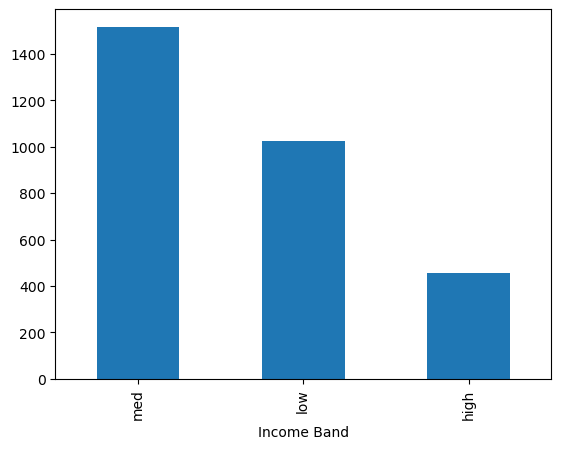

In [23]:
df['Income Band'].value_counts().plot(kind='bar')

In [25]:
#examine the distribution of unique categories in categorical columns
# list of categorical columns
categorical_cols = [
    "BRId","GenderId","IAId","Amount of Credit Cards","Nationality",
    "Occupation","Fee Structure","Loyalty Classification",
    "Properties Owned","Risk Weighting","Income Band"
]

# print value counts for each
for col in categorical_cols:
    print(f"\nValue counts for '{col}':")
    display(df[col].value_counts(dropna=False))



Value counts for 'BRId':


BRId
3    1352
1     660
2     495
4     493
Name: count, dtype: int64


Value counts for 'GenderId':


GenderId
2    1512
1    1488
Name: count, dtype: int64


Value counts for 'IAId':


...

Properties Owned
2    777
1    776
3    742
0    705
Name: count, dtype: int64


Value counts for 'Risk Weighting':


Risk Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64


Value counts for 'Income Band':


Income Band
med     1517
low     1027
high     456
Name: count, dtype: int64

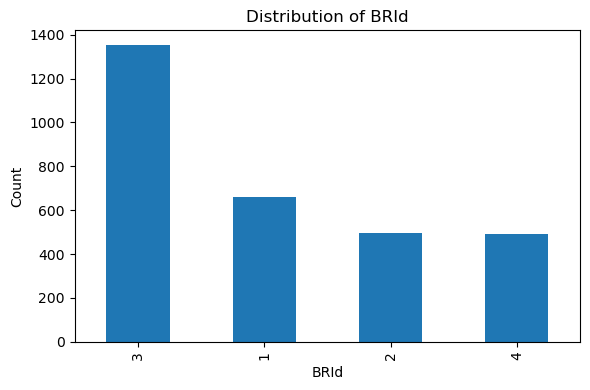

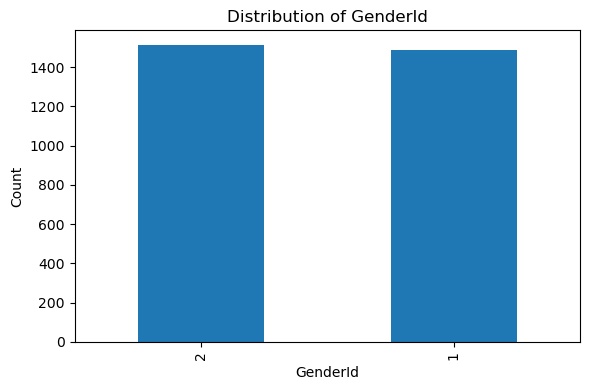

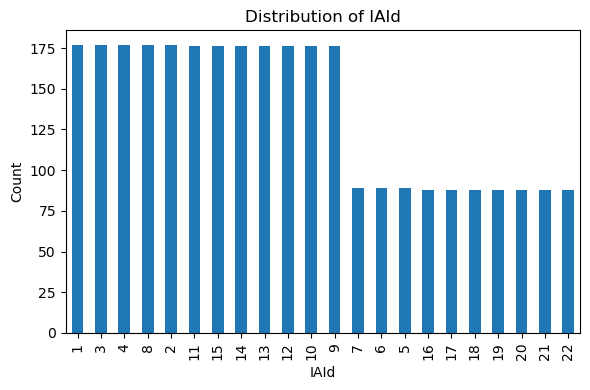

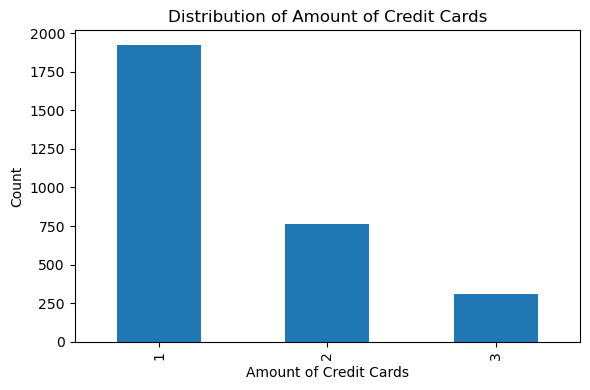

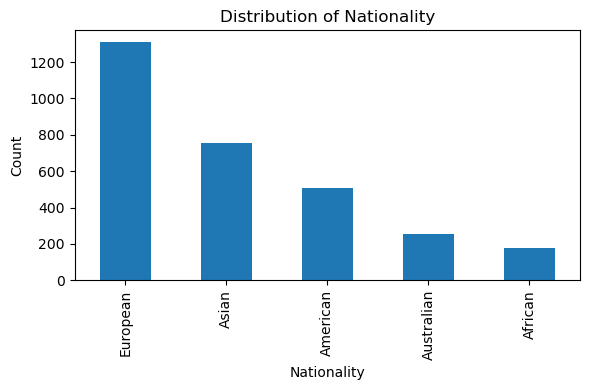

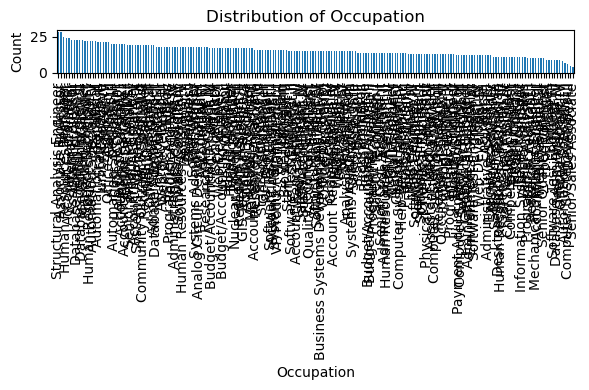

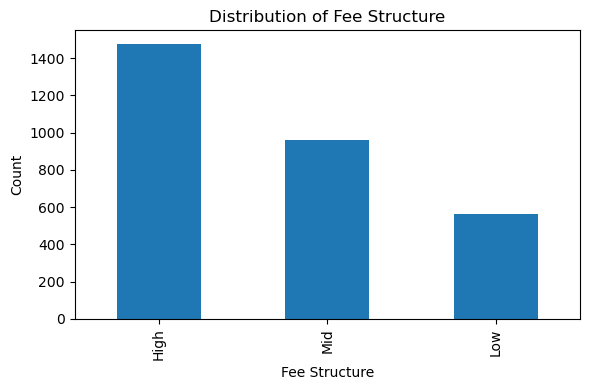

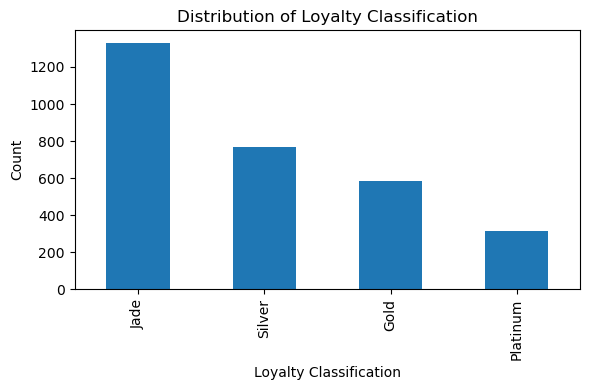

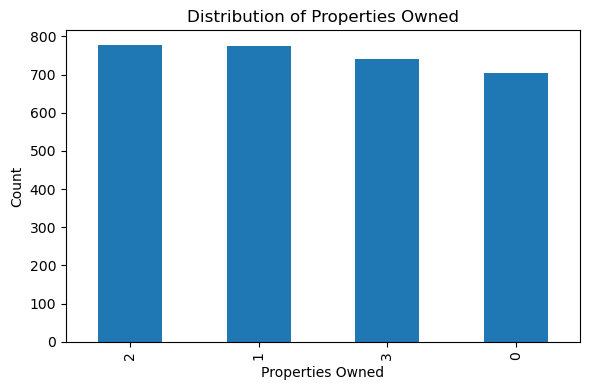

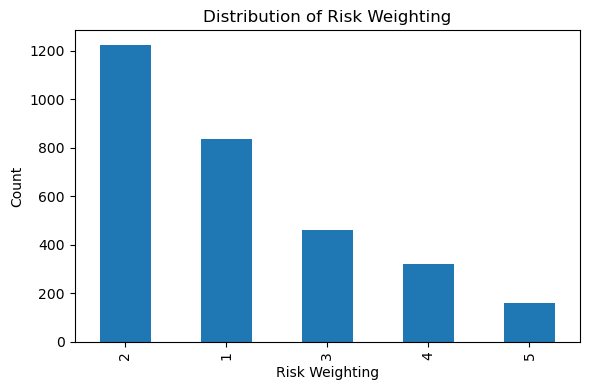

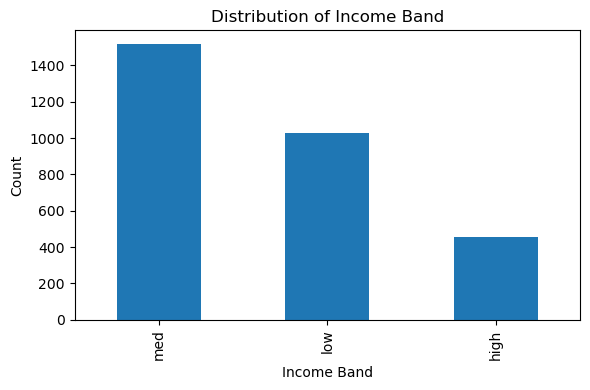

In [26]:
import matplotlib.pyplot as plt

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


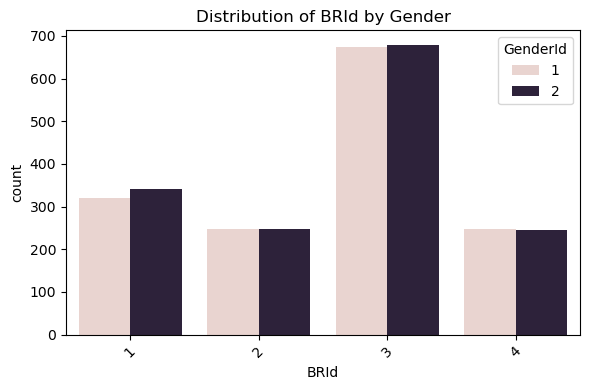

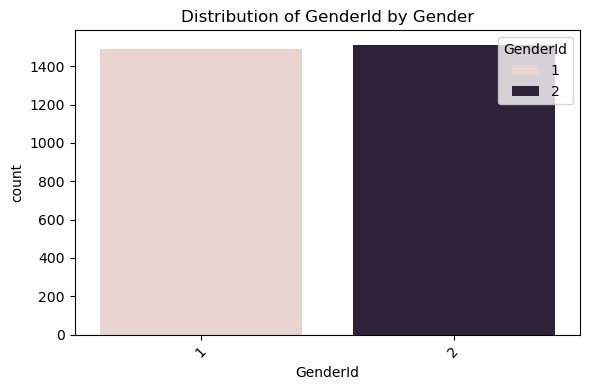

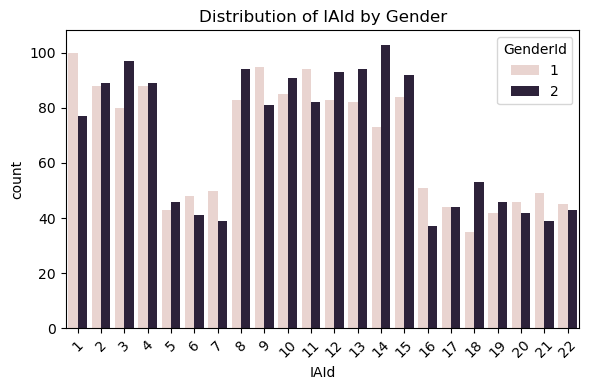

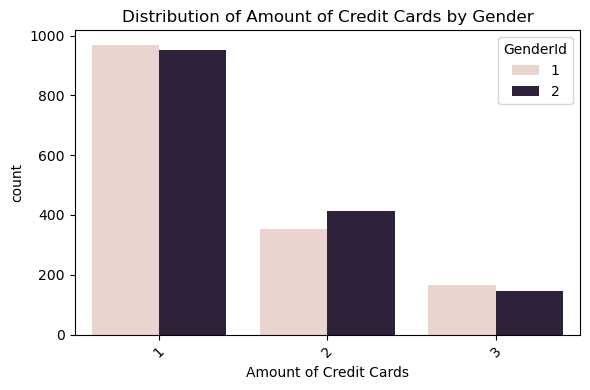

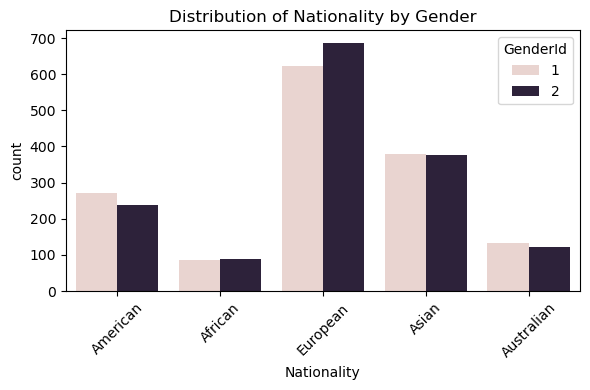

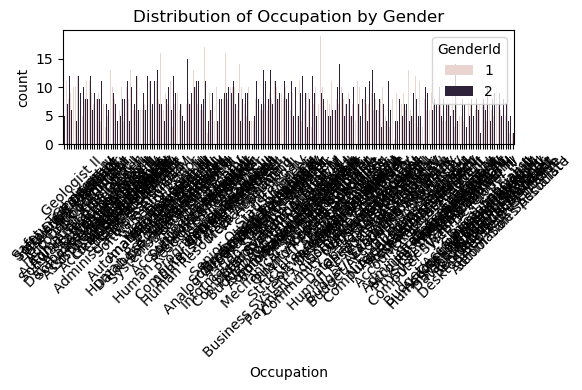

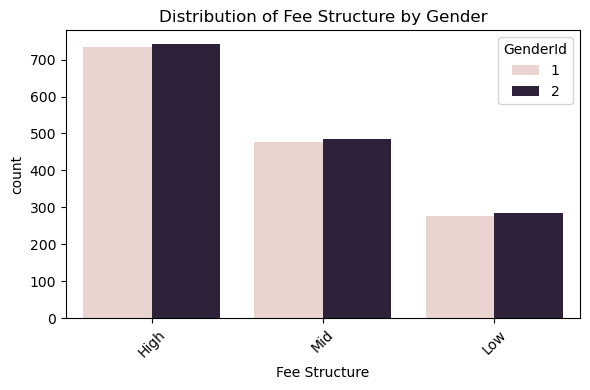

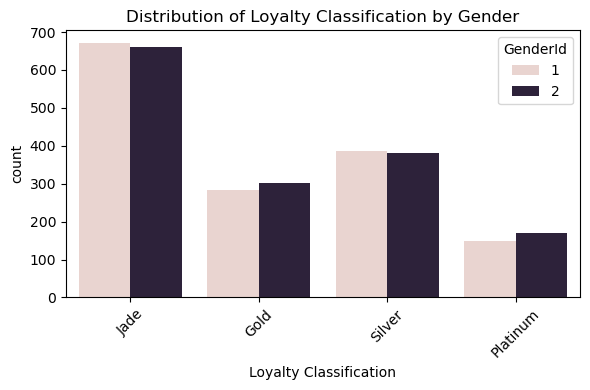

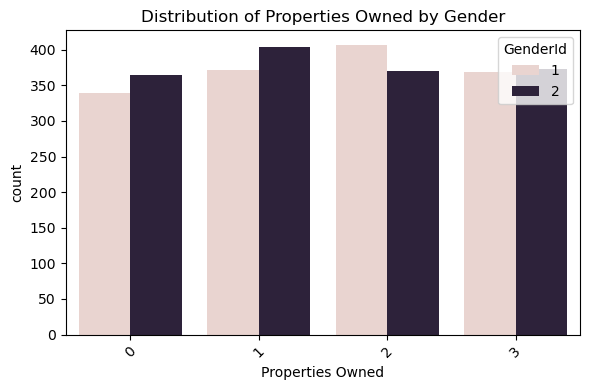

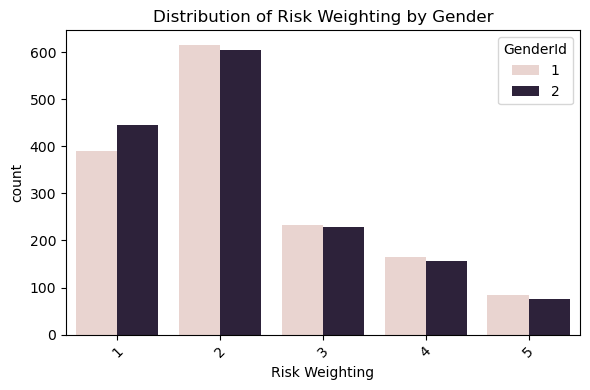

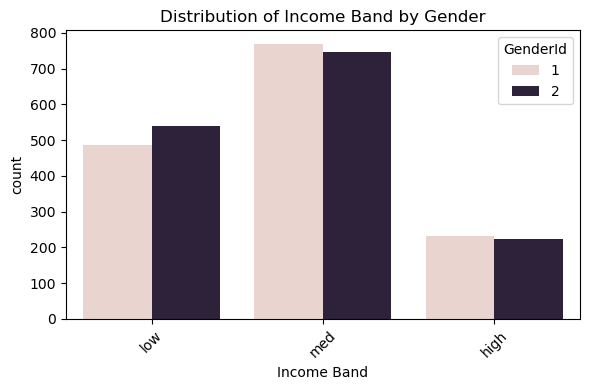

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of categorical columns to visualize
cols = ['BRId', 'GenderId', 'IAId', 'Amount of Credit Cards', 'Nationality', 'Occupation', 
        'Fee Structure', 'Loyalty Classification', 'Properties Owned', 'Risk Weighting', 'Income Band']

# Loop to generate countplots
for i, predictor in enumerate(cols):
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=predictor, hue='GenderId')
    plt.title(f"Distribution of {predictor} by Gender")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

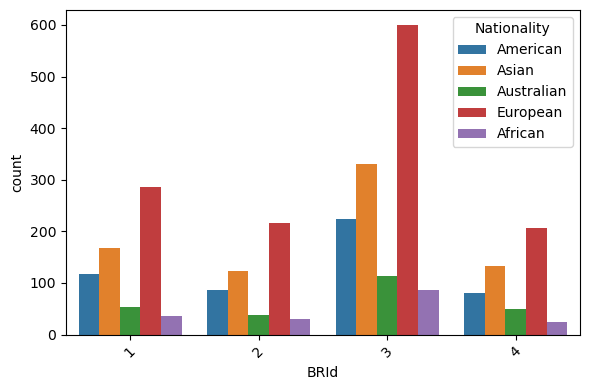

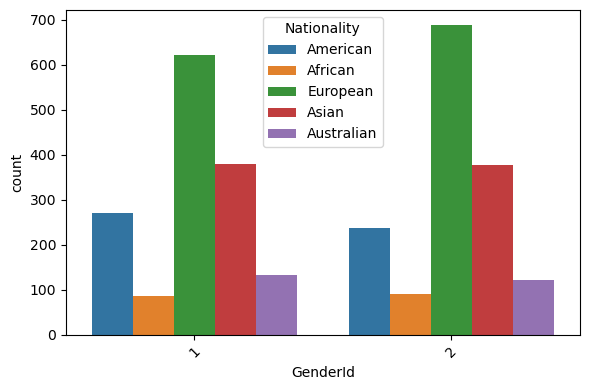

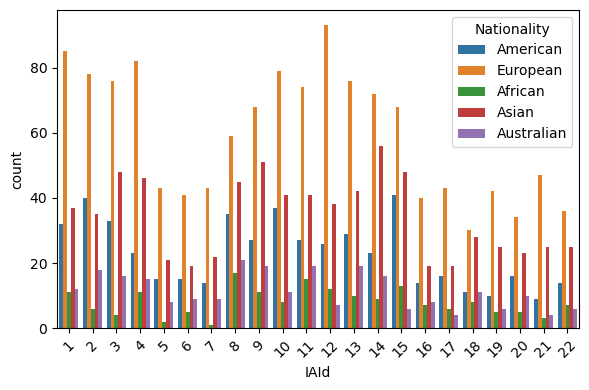

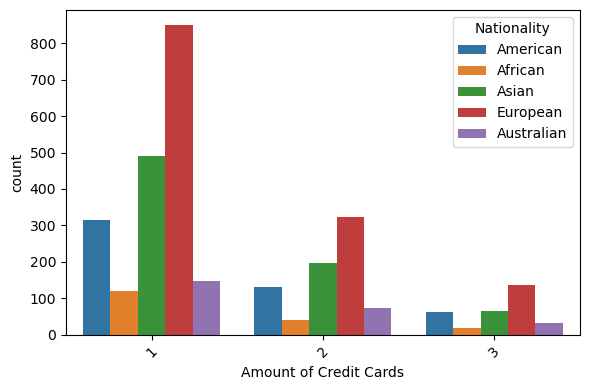

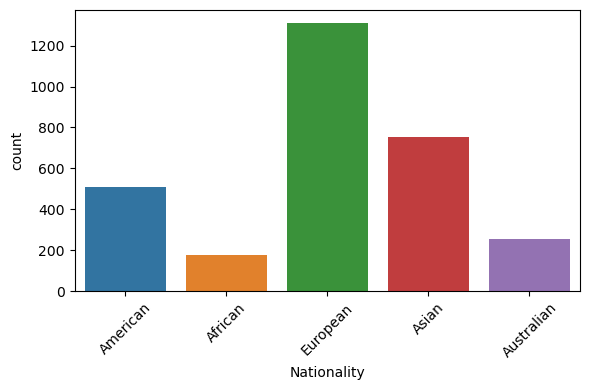

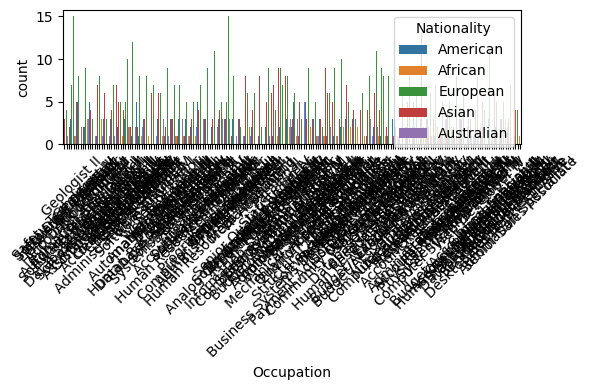

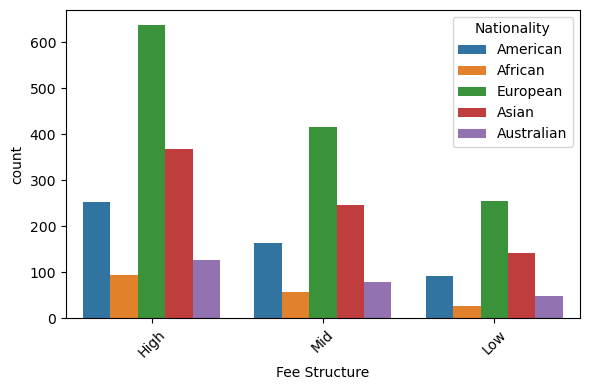

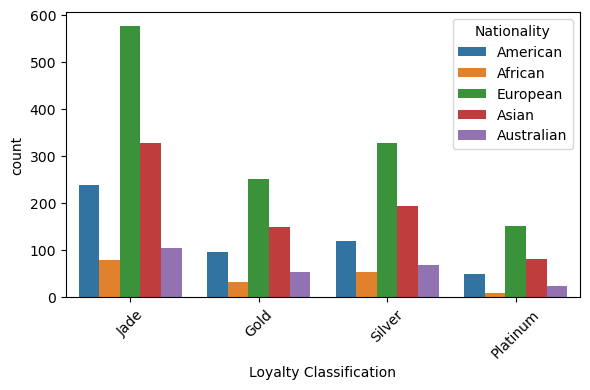

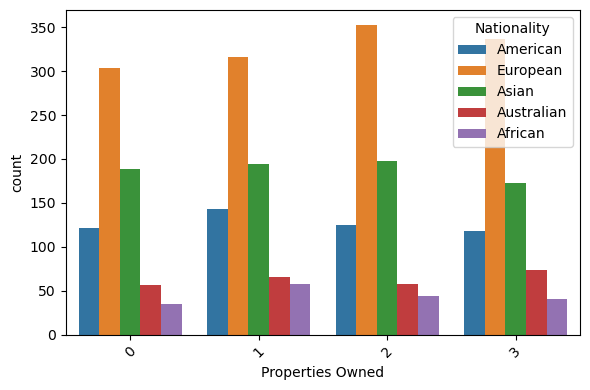

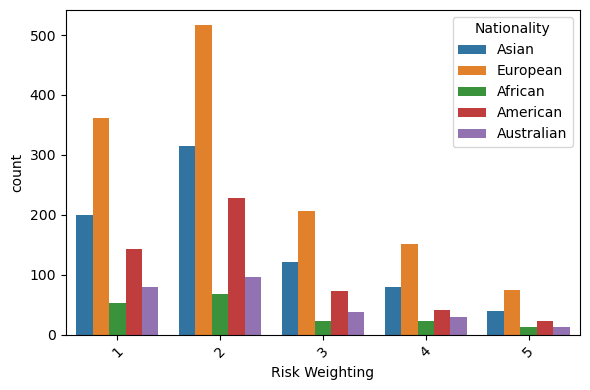

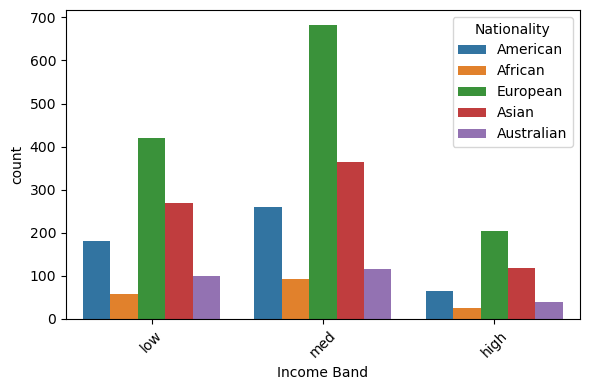

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = ['BRId', 'GenderId', 'IAId', 'Amount of Credit Cards', 
           'Nationality', 'Occupation', 'Fee Structure', 
           'Loyalty Classification', 'Properties Owned', 
           'Risk Weighting', 'Income Band']

for predictor in columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=predictor, hue='Nationality')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Count Plots for Categorical Variables:



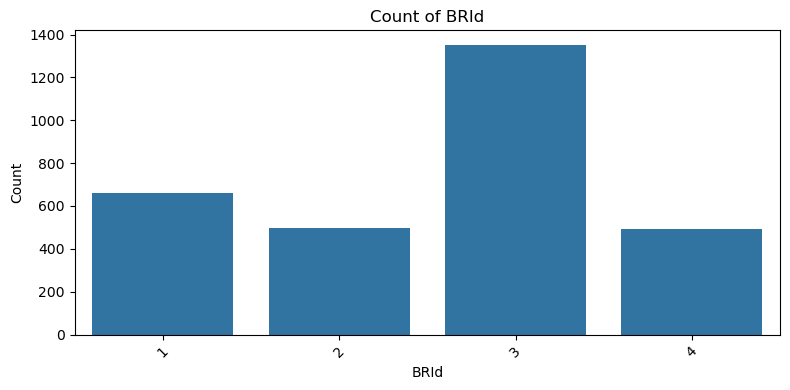

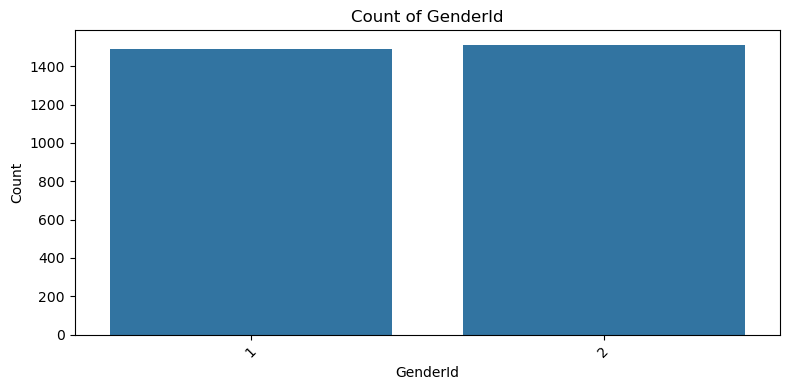

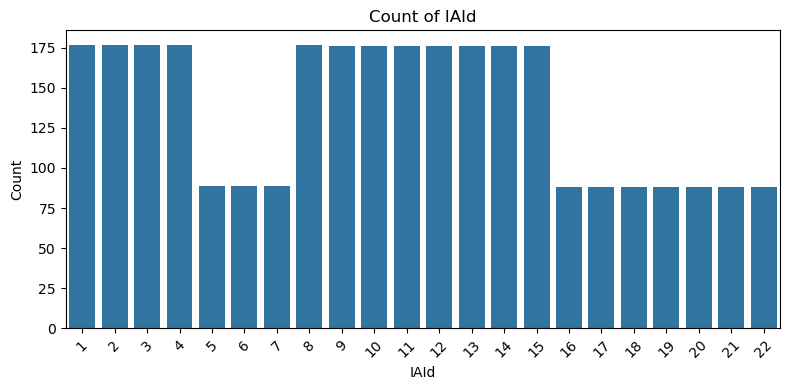

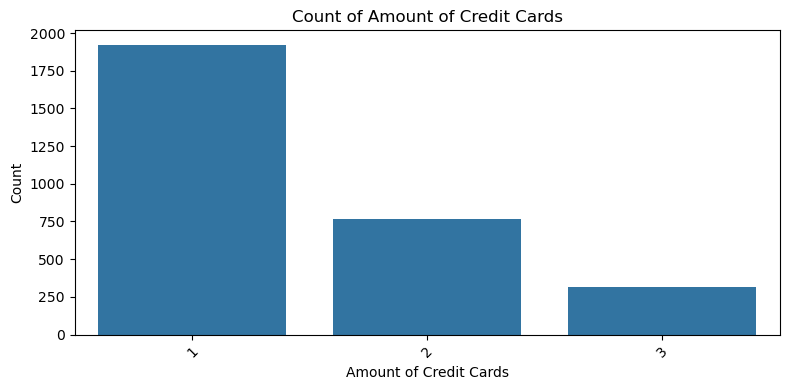

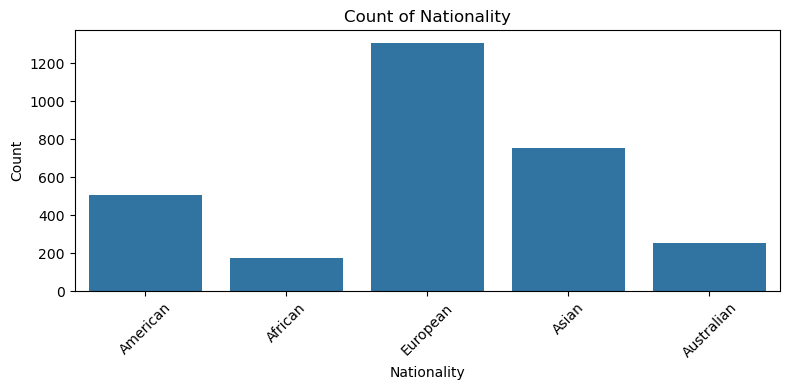

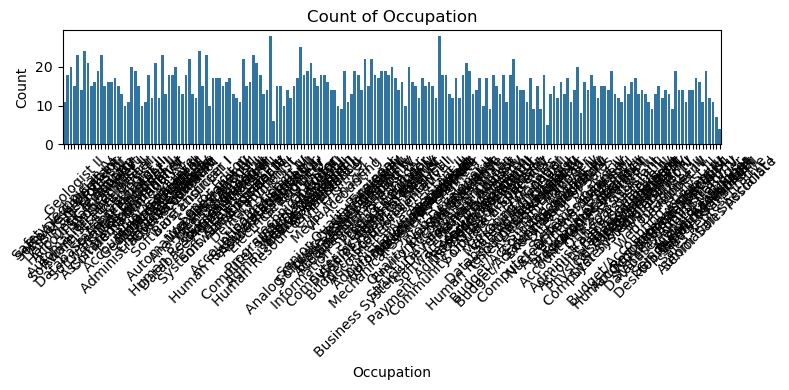

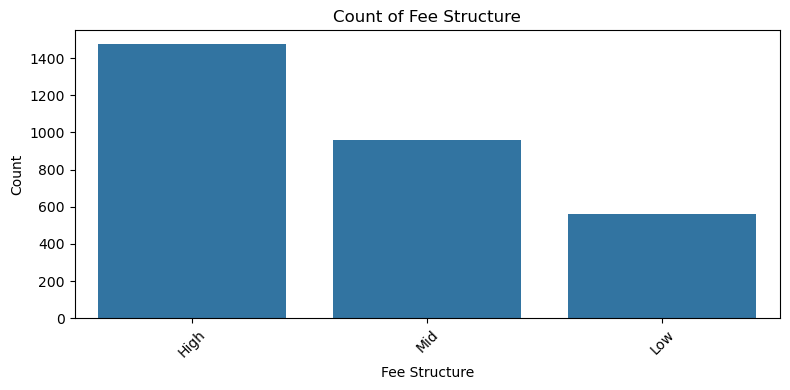

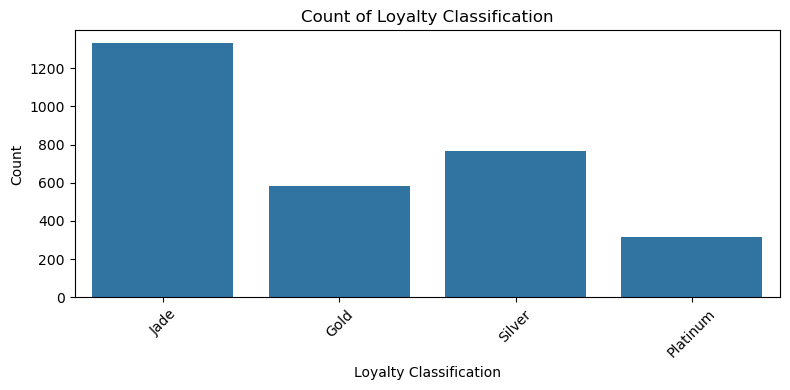

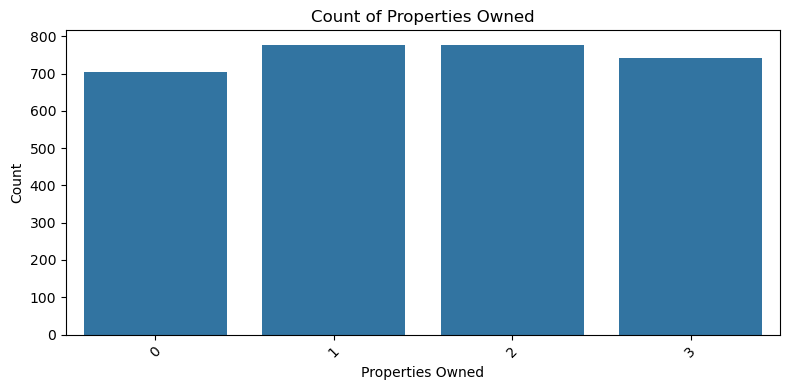

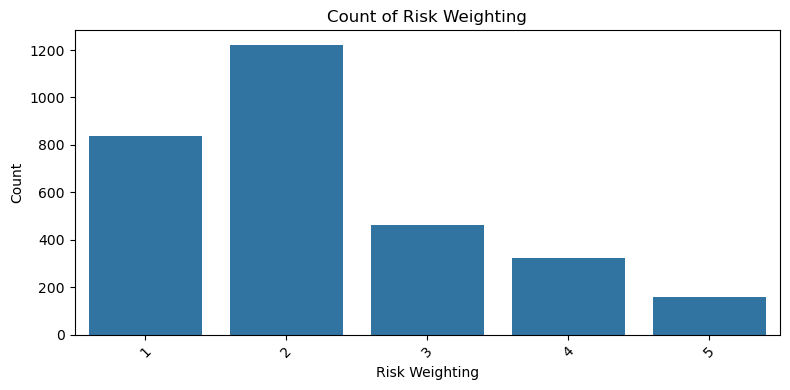

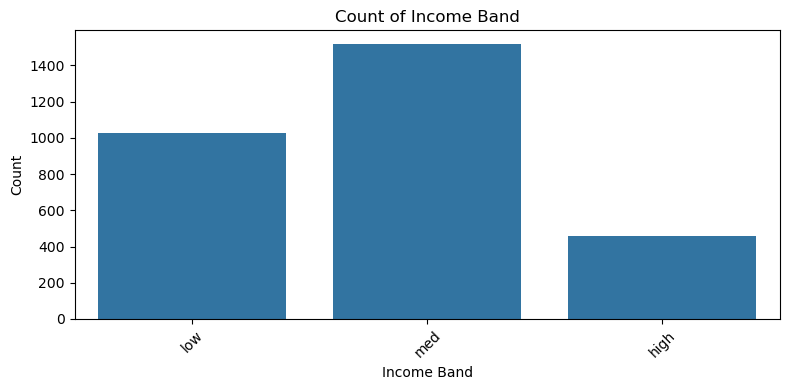


Histogram of Amount of Credit Cards across different Occupations:



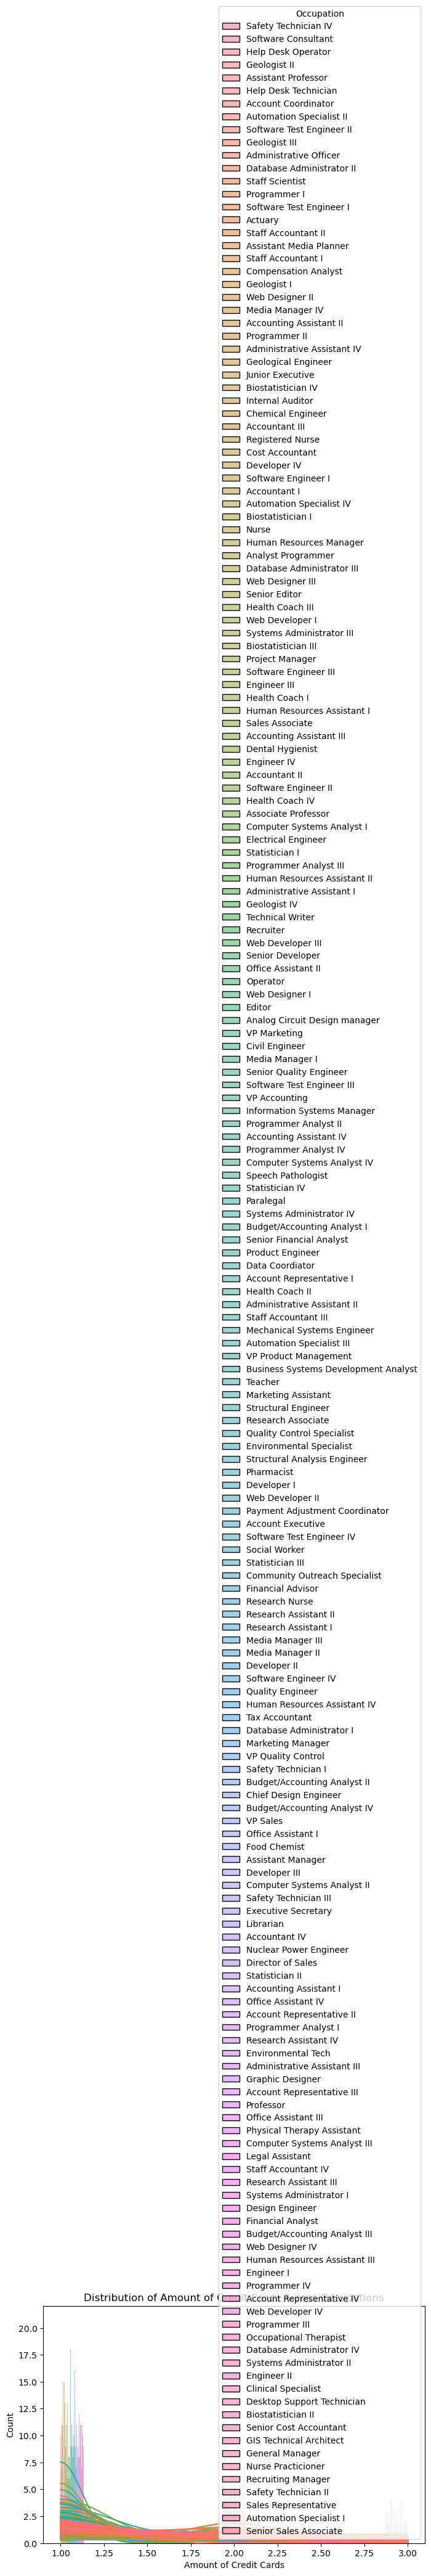

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame name is df
# If not, replace df with your dataset variable name

# 1. Identify categorical columns
categorical_cols = ['BRId', 'GenderId', 'IAId', 'Amount of Credit Cards', 
                    'Nationality', 'Occupation', 'Fee Structure', 
                    'Loyalty Classification', 'Properties Owned', 
                    'Risk Weighting', 'Income Band']

# 2. Countplots for all categorical variables
print("Count Plots for Categorical Variables:\n")

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3. Histogram of a numeric variable based on Occupation
# Choose the numeric variable you want to compare across Occupation
num_col = 'Amount of Credit Cards'  # Change if needed (Ex: 'Income', 'Balance', 'Age', etc.)

print(f"\nHistogram of {num_col} across different Occupations:\n")

plt.figure(figsize=(8,5))
sns.histplot(data=df.dropna(subset=[num_col, 'Occupation']),
             x=num_col,
             hue='Occupation',
             multiple='dodge',
             kde=True,
             bins=15)
plt.title(f"Distribution of {num_col} Across Occupations")
plt.xlabel(num_col)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

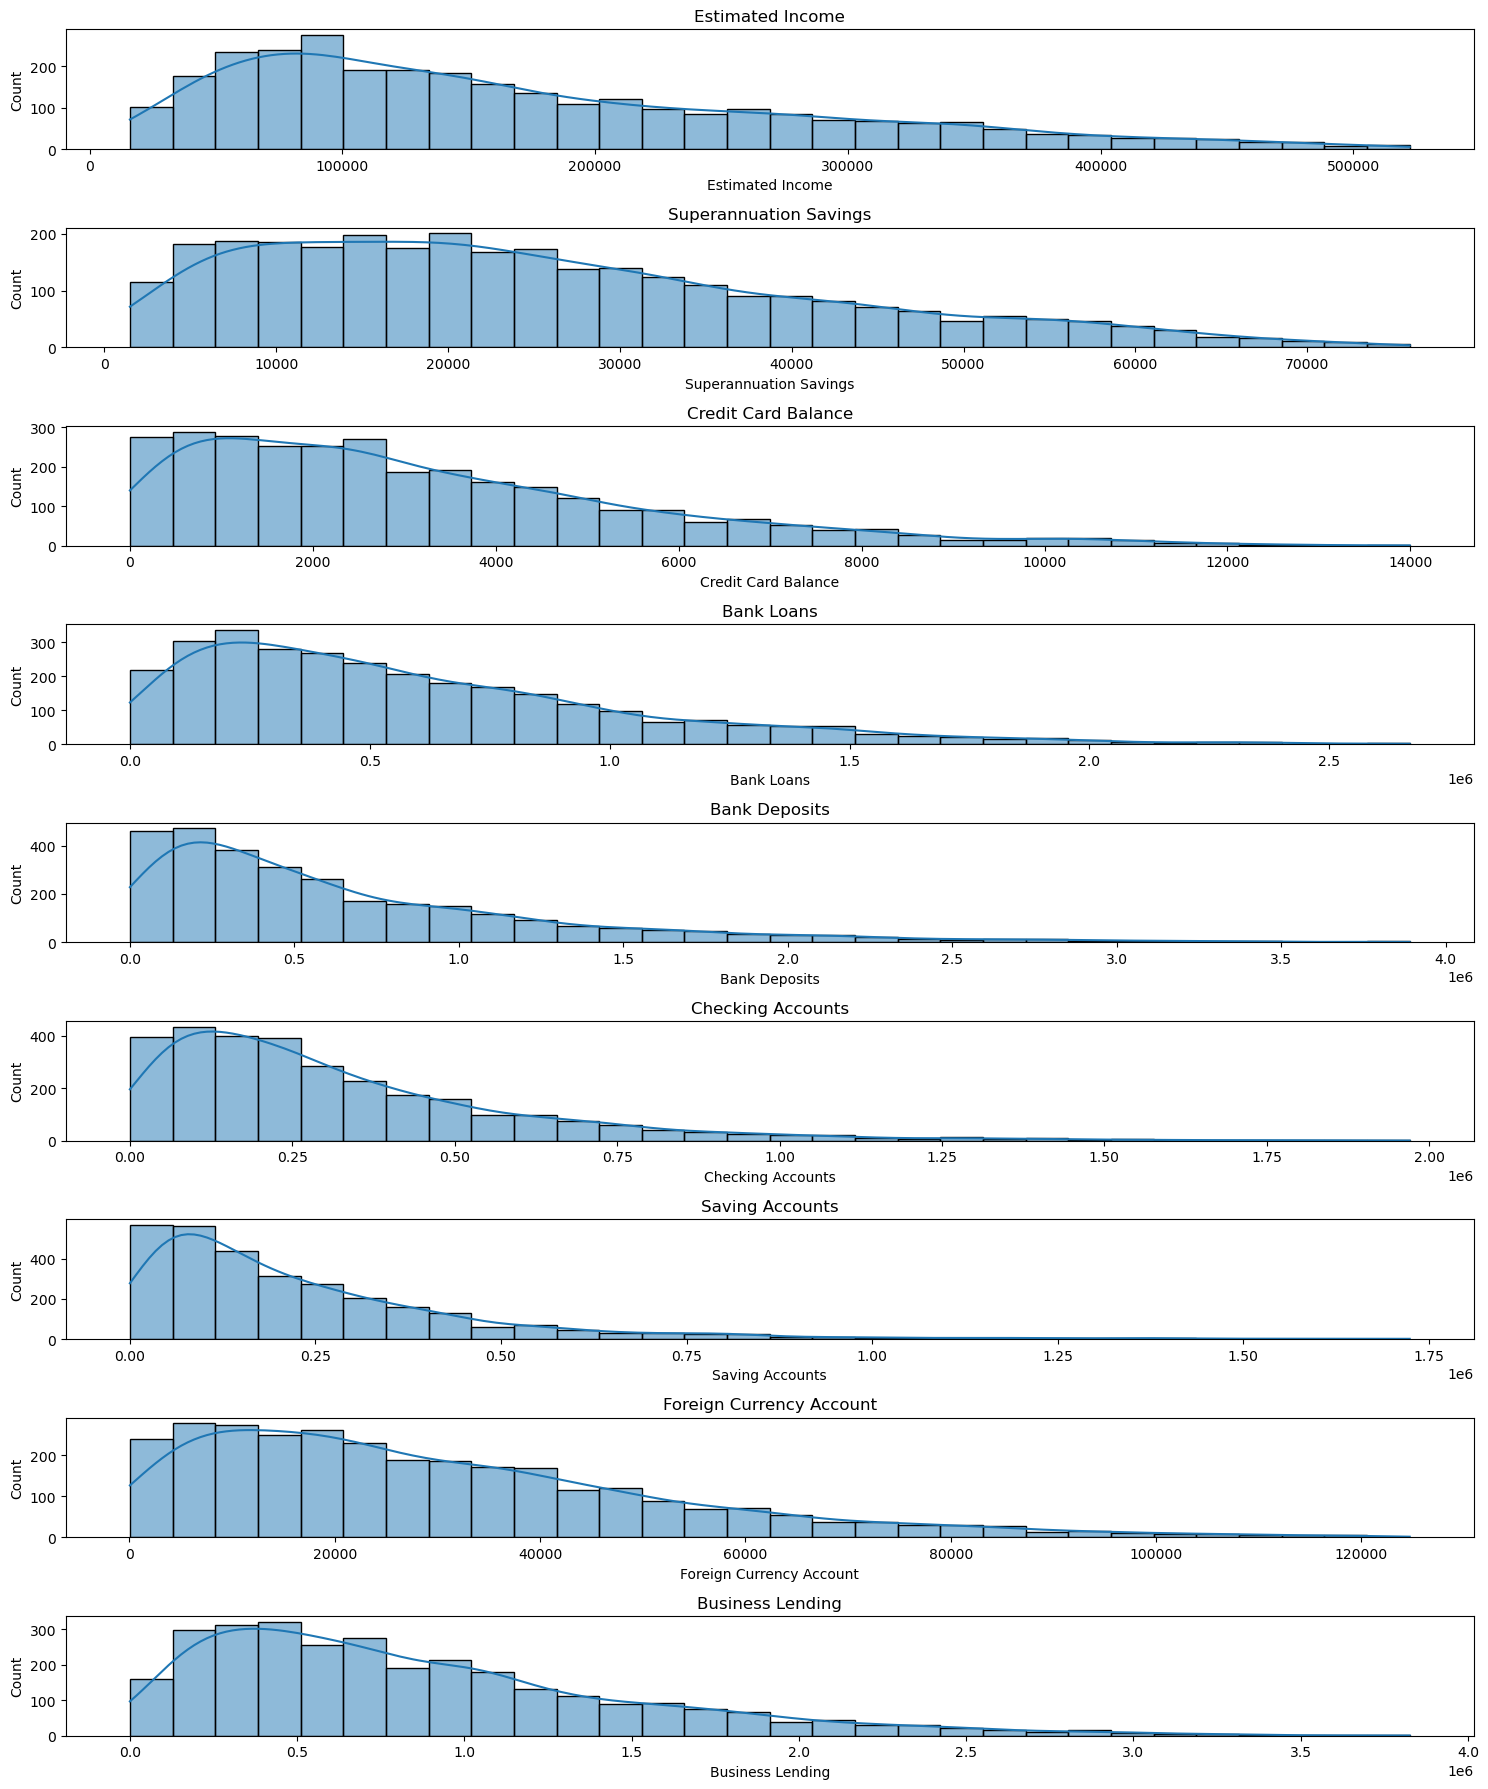

['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank', 'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure', 'Loyalty Classification', 'Estimated Income', 'Superannuation Savings', 'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending', 'Properties Owned', 'Risk Weighting', 'BRId', 'GenderId', 'IAId', 'Tenure_Y', 'CreditUtilization', 'LoanToIncome', 'DepositToLoan', 'CardsPerIncome', 'TotalAccounts', 'RiskWeighting', 'HighRisk', 'RiskScore', 'RiskDecile', 'RiskBand', 'Income Band']


In [41]:
numerical_cols = [
    'Estimated Income', 'Superannuation Savings', 'Credit Card Balance',
    'Bank Loans', 'Bank Deposits', 'Checking Accounts',
    'Saving Accounts', 'Foreign Currency Account', 'Business Lending'
]
plt.figure(figsize=(15, 18))   # Bigger height for more subplots

for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols), 1, i+1)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()
print(df.columns.tolist())


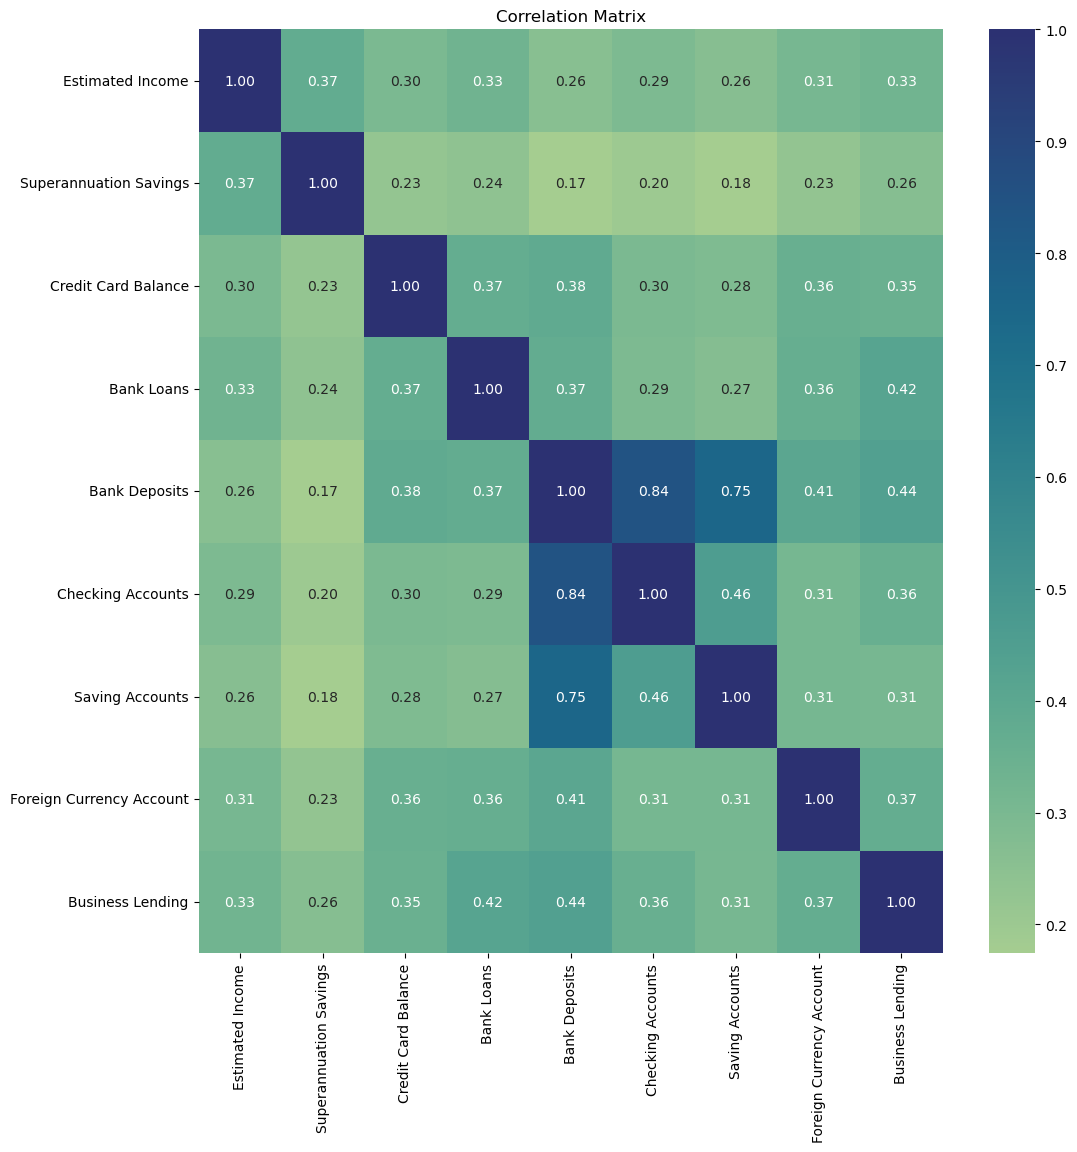

In [42]:
# Heatmaps

numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()
